# Calibration experiment

**Synthetic calibration data — for prototype demonstration only.**

This notebook walks through the ML layer of the Tile Colour Calibration Engine. The data is generated, not measured on any client printer. A real pilot needs paired printer-input and post-fire spectrophotometer measurements.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

from src.calibration_model import FORWARD_EFFECT, generate_synthetic_calibration, train_model
from src.recommendation import recommend
from src.utils import FEATURES, SYNTHETIC_LABEL, TARGETS

print(SYNTHETIC_LABEL)

Synthetic calibration data — for prototype demonstration only.


## 1. Synthetic dataset

Each row is one invented historical correction: the Lab deviation of a production tile from its master (production minus master) and the printer adjustment that removed it.

In [2]:
frame = generate_synthetic_calibration()
frame.drop(columns='data_source').describe().round(2)

,delta_L,delta_a,delta_b,brown_adjustment,yellow_adjustment,cyan_adjustment,magenta_adjustment
count,600.00,600.00,600.00,600.00,600.00,600.00,600.00
mean,-0.10,0.20,0.03,-0.14,0.03,0.11,-0.11
std,3.17,3.69,3.88,3.48,3.49,3.56,3.44
min,-6.90,-8.52,-9.67,-5.99,-5.99,-5.95,-5.98
25%,-2.63,-2.40,-2.93,-3.18,-2.91,-2.94,-3.26
50%,-0.28,0.21,0.12,-0.28,-0.12,-0.10,0.05
75%,2.48,2.65,2.86,2.94,3.29,3.37,2.83
max,7.07,10.36,9.06,5.99,5.99,6.00,5.99


## 2. Train a Ridge model (fixed seed, 80/20 split)

In [3]:
bundle = train_model(frame)
print('Model trained on synthetic calibration data.')
print(f"MAE (mean): {bundle.metrics['mae_mean']:.2f} percentage points")
print(f"R2  (mean): {bundle.metrics['r2_mean']:.2f}")
import pandas as pd
pd.DataFrame({'MAE': bundle.metrics['mae_per_channel'], 'R2': bundle.metrics['r2_per_channel']}).round(2)

Model trained on synthetic calibration data.
MAE (mean): 1.34 percentage points
R2  (mean): 0.75


,MAE,R2
brown_adjustment,0.76,0.92
yellow_adjustment,1.32,0.78
cyan_adjustment,1.55,0.66
magenta_adjustment,1.73,0.64


**Reading the result honestly.** Four channels are predicted from only three colour dimensions (L*, a*, b*). Different channel mixes can produce the same colour change, so the problem is under-determined and the per-channel R² is moderate by construction. A real pilot would use more measurements (for example several regions per tile) or restrict which channels may move.

In [4]:
bundle.coefficients.round(3)

,delta_L,delta_a,delta_b,intercept
brown_adjustment,0.943,-0.096,-0.295,-0.023
yellow_adjustment,-0.245,0.027,-0.777,0.038
cyan_adjustment,0.563,0.676,0.253,0.036
magenta_adjustment,0.169,-0.620,0.217,0.041


## 3. Predicted vs actual (held-out style view on the full synthetic set)

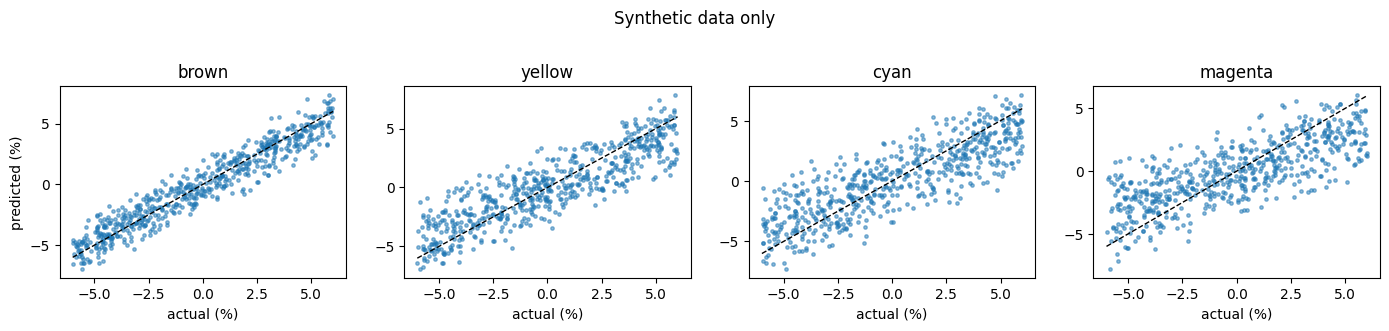

In [5]:
x = frame[list(FEATURES)].to_numpy()
y = frame[list(TARGETS)].to_numpy()
pred = bundle.predict(x)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for i, ax in enumerate(axes):
    ax.scatter(y[:, i], pred[:, i], s=6, alpha=0.5)
    ax.plot([-6, 6], [-6, 6], 'k--', lw=1)
    ax.set_title(TARGETS[i].replace('_adjustment', ''))
    ax.set_xlabel('actual (%)')
axes[0].set_ylabel('predicted (%)')
plt.suptitle('Synthetic data only', y=1.02)
plt.tight_layout()
plt.show()

## 4. Does the recommendation close the colour gap?

Applying the model's adjustments through the *invented* forward effect matrix shows how much of the synthetic colour error would remain. This checks the ML layer only. It says nothing about a real printer.

**Caution:** the near-total reduction is an artefact. The synthetic data was generated from this same linear matrix, so the model can invert it almost perfectly. A real printer, kiln and glaze will not behave this cleanly, and this result must not be read as expected real-world accuracy.

In [6]:
residual = x + pred @ FORWARD_EFFECT.T
before = np.linalg.norm(x, axis=1).mean()
after = np.linalg.norm(residual, axis=1).mean()
print(f'Mean synthetic dE before: {before:.2f}')
print(f'Mean synthetic dE after:  {after:.2f}  ({1 - after / before:.0%} reduction)')

Mean synthetic dE before: 5.83
Mean synthetic dE after:  0.02  (100% reduction)


## 5. Range check and out-of-range handling

In [7]:
inside = recommend(2.5, 1.2, -1.5, bundle)
outside = recommend(14.0, 9.0, -12.0, bundle)
print('Inside :', inside.status, {k: round(v, 1) for k, v in inside.adjustments.items()})
print('Outside:', outside.status, outside.adjustments)
print(outside.messages[0])

Inside : Within calibration range {'brown': 2.7, 'yellow': 0.6, 'cyan': 1.9, 'magenta': -0.6}
Outside: Outside calibration range None
LOW CONFIDENCE / OUTSIDE CALIBRATION RANGE


Human/QC validation required before production use.